In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df=pd.read_excel("/content/Raw Data January.xlsx", skiprows=2)

df.head()

,Date and Time,Unnamed: 1,FPE.Meteo01.sensor_row_a17.Irradiation,FPE.Meteo01.sensor_row_b22.Irradiation,FPE.Meteo01.sensor_row_b24.Irradiation,FPE.Meteo02.sensor_row_a05.Irradiation,FPE.Meteo02.sensor_row_a06.Irradiation,FPE.Meteo02.sensor_row_b11.Irradiation,Unnamed: 8,Power.Analyzer_Schneider_ION.Active Power Total,...,Unnamed: 12,Inverter.01.AC_active_power,Inverter.02.AC_active_power,Inverter.03.AC_active_power,When Max Solar Irradiance is higher than 1,Unnamed: 17,Unnamed: 18,Inverters down time,Unnamed: 20,Unnamed: 21
0,NaN,NaN,[W/mÂ²],[W/mÂ²],[W/mÂ²],[W/mÂ²],[W/mÂ²],[W/mÂ²],Irradiation Tilted (kWh/m2),NaN,...,Average Module Temp (C°),[kW],[kW],[kW],Inverter 1 useful time,Inverter 2 useful time,Inverter 3 useful time,Inverter 1 down time,Inverter 2 down time,Inverter 3 down time
1,01.01.2021,00:00:00,0,0,0,0,0,0,0,14.0,...,,0,0,0,0,0,0,0.916162,0.998605,0.997962
2,01.01.2021,00:01:00,0,0,0,0,0,0,0,14.0,...,,0,0,0,0,0,0,NaN,NaN,NaN
3,01.01.2021,00:02:00,0,0,0,0,0,0,0,14.0,...,,0,0,0,0,0,0,NaN,NaN,NaN
4,01.01.2021,00:03:00,0,0,0,0,0,0,0,14.0,...,,0,0,0,0,0,0,NaN,NaN,NaN


In [4]:
power_cols = [
    'Inverter.01.AC_active_power',
    'Inverter.02.AC_active_power',
    'Inverter.03.AC_active_power'
]

In [5]:
irr_cols = [col for col in df.columns if 'Irradiation' in col]

In [6]:
for col in power_cols + irr_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [7]:
df['Max_Solar_Irradiance'] = df[irr_cols].max(axis=1)

In [8]:
df_useful = df[df['Max_Solar_Irradiance'] > 1].copy()

In [9]:
print(f"the cleaned data : {len(df_useful)} daylight minutes identified")

the cleaned data : 19884 daylight minutes identified


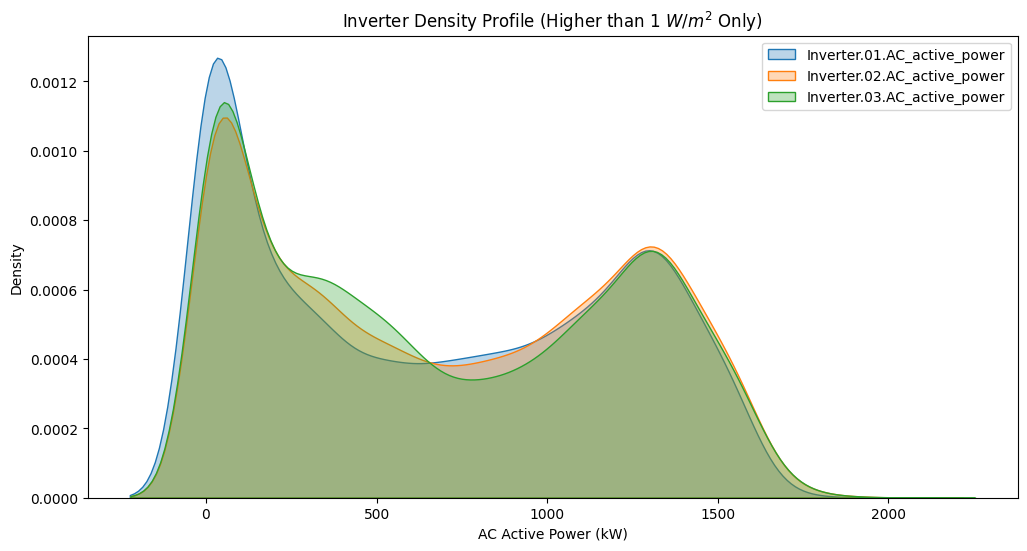

In [10]:
plt.figure(figsize=(12, 6))
for col in power_cols:
    sns.kdeplot(df_useful[col], label=col, fill=True, alpha=0.3)
plt.title("Inverter Density Profile (Higher than 1 $W/m^2$ Only)")
plt.xlabel("AC Active Power (kW)")
plt.ylabel("Density")
plt.legend()
plt.show()

#much messier, there is more variability and more spread out, may be due to  nonuniform sun angles and shading on the inverters

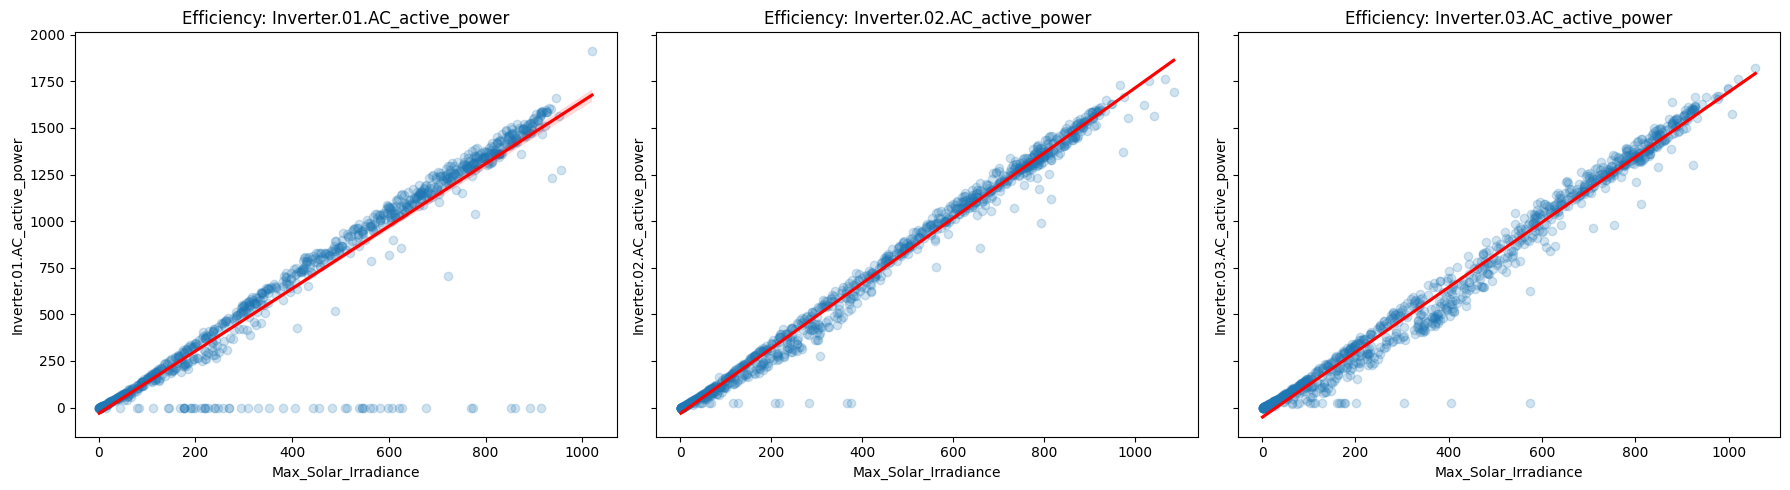

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for i, col in enumerate(power_cols):
    sns.regplot(x='Max_Solar_Irradiance', y=col, data=df_useful.sample(1000),
                ax=axes[i], scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
    axes[i].set_title(f"Efficiency: {col}")
plt.tight_layout()
plt.show()

#By starting the regression at the moment the sun hits the panels, im ensuring the efficiency calculation isnt being ruined by nighttime zeros

In [12]:
stats = df_useful[power_cols].describe().T
stats['Skewness'] = df_useful[power_cols].skew()
stats['Kurtosis'] = df_useful[power_cols].kurtosis()
print(stats[['mean', 'std', 'max', 'Skewness', 'Kurtosis']])

#the std dev ~530 kW is very high relative to the mean -> high volatility, the system is frequently jumping between low power and high power
#the skewness is positive
#negative kurtosis demonstrates that production is spread widely across the power range rather than peaking at a single value

                                   mean         std     max  Skewness  \
Inverter.01.AC_active_power  667.655567  532.073955  1980.0  0.168370   
Inverter.02.AC_active_power  707.336268  528.442953  2000.6  0.130501   
Inverter.03.AC_active_power  688.055562  528.899740  2035.1  0.204187   

                             Kurtosis  
Inverter.01.AC_active_power -1.451588  
Inverter.02.AC_active_power -1.426659  
Inverter.03.AC_active_power -1.406611  


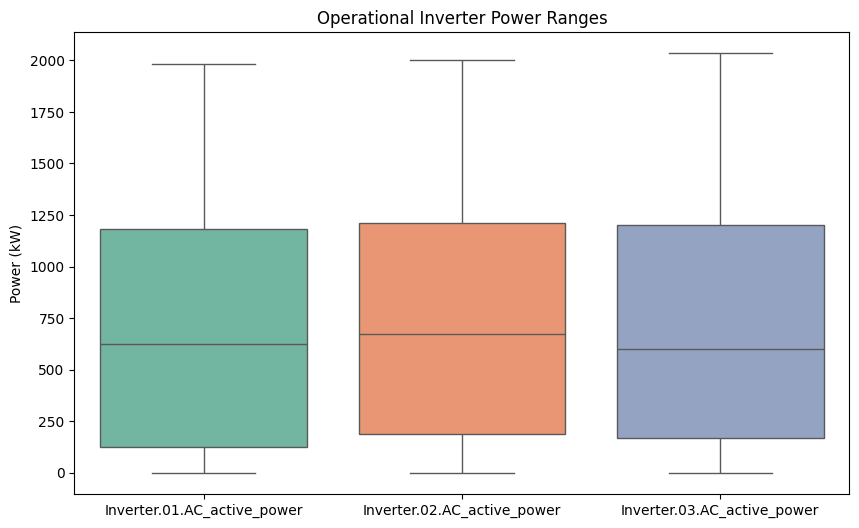

In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_useful[power_cols], palette="Set2")
plt.title("Operational Inverter Power Ranges")
plt.ylabel("Power (kW)")
plt.savefig('boxplot_exploration.png')

#boxes dont sit at the same height
#inverter 2 is more productive
#compressed boxes compared to july -> seasonal de-rating of the power plant, winter isnt helping in pushing energy
#while the cold jan air allows for high instantaneous peaks (whiskers), the system spends very little actual time at those levels because the solar window is so short

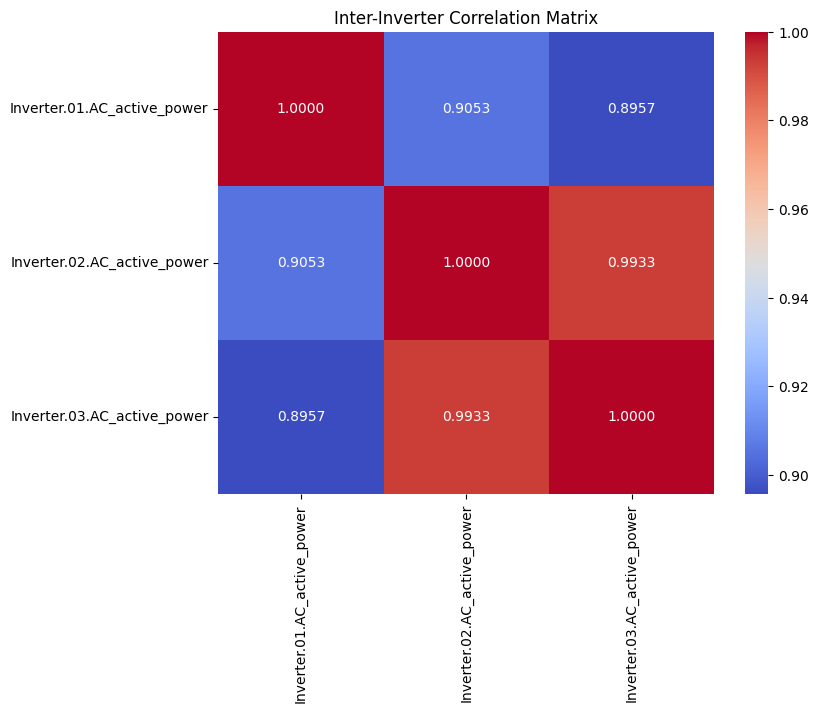

In [14]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_useful[power_cols].corr(), annot=True, cmap='coolwarm', fmt=".4f")
plt.title("Inter-Inverter Correlation Matrix")
plt.savefig('heatmap_exploration.png')


#high synch too
#same things as before if one fails others would drop too

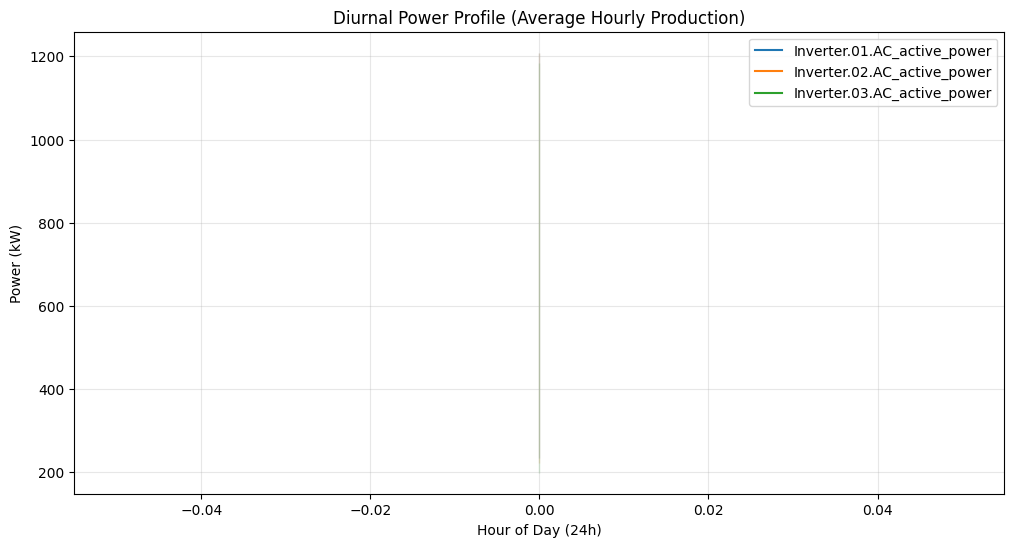

In [20]:
df_useful['DateTime'] = pd.to_datetime(df_useful['Date and Time'], errors='coerce')
df_useful['Hour'] = df_useful['DateTime'].dt.hour

plt.figure(figsize=(12, 6))
for col in power_cols:
    sns.lineplot(data=df_useful, x='Hour', y=col, label=col, errorbar='sd')
plt.title("Diurnal Power Profile (Average Hourly Production)")
plt.ylabel("Power (kW)")
plt.xlabel("Hour of Day (24h)")
plt.grid(True, alpha=0.3)
plt.show()


#idk

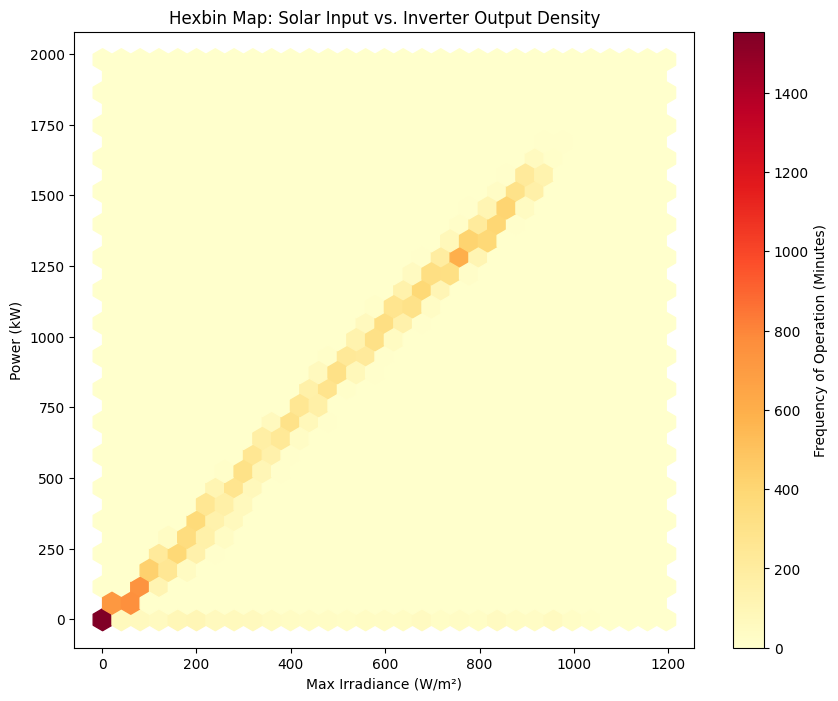

In [21]:
plt.figure(figsize=(10, 8))
plt.hexbin(df_useful['Max_Solar_Irradiance'], df_useful[power_cols[0]], gridsize=30, cmap='YlOrRd')
plt.colorbar(label='Frequency of Operation (Minutes)')
plt.title("Hexbin Map: Solar Input vs. Inverter Output Density")
plt.xlabel("Max Irradiance (W/m²)")
plt.ylabel("Power (kW)")
plt.show()

#less power, highest is around 1700 kW
#system is still efficient

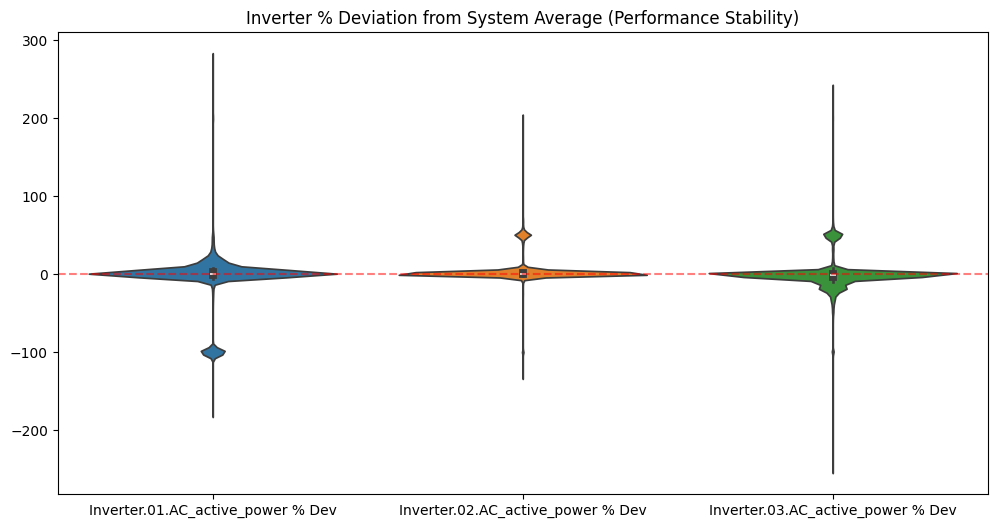

In [22]:
df_useful['System_Mean'] = df_useful[power_cols].mean(axis=1)
dev_data = pd.DataFrame()
for col in power_cols:
    dev_data[f'{col} % Dev'] = ((df_useful[col] - df_useful['System_Mean']) / df_useful['System_Mean']) * 100

plt.figure(figsize=(12, 6))
sns.violinplot(data=dev_data.replace([np.inf, -np.inf], np.nan).dropna())
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.title("Inverter % Deviation from System Average (Performance Stability)")
plt.show()


#fatter with and more spread, the inverters are drifting away from each other much more often in winter
#when a shadow hits one row of panels but not the others, that inverter drops relative to the average -> stretching the violin downward
#inverter 1 underperfoms (look at the tail stretching down) -> could be because of shading or dust accumilation
#lumps due to frequently switching between the two states: high efficiency unshaded and low efficiency when shaded